In [7]:
# Open Topography API key:     2f710d1cfe0e44cec6d8a7c8efb755fe     cf3eebbeec359767ac57f6e86eb206ac
import os
import warnings

import numpy as np
import pandas as pd
import xarray
from datetime import datetime
import cftime
import matplotlib.pyplot as plt
from matplotlib import colors
from bmi_topography import Topography
from landlab import RasterModelGrid

#import imageio.v2 as imageio
#from IPython.display import Video
#from tqdm import trange
#from pymt.models import Topography



In [12]:
lat, lon = (48.571477, -120.943695)  # Hunter Creek U-Valley Location
height, width = 0.02, 0.02 # Defines extent of DEM Scope

longs_peak_dem = Topography(
    north=lat + height,
    south=lat - height,
    east=lon + width,
    west=lon - width,
    output_format='GTiff',
    dem_type="SRTMGL3",
    api_key='cf3eebbeec359767ac57f6e86eb206ac',
)
    
longs_peak = longs_peak_dem.load()
#print(f"Shape of the data = {longs_peak.values.shape}")
#print(f"Minimum elevation = {longs_peak.values.min()}")
#print(f"Maximum elevation = {longs_peak.values.max()}")

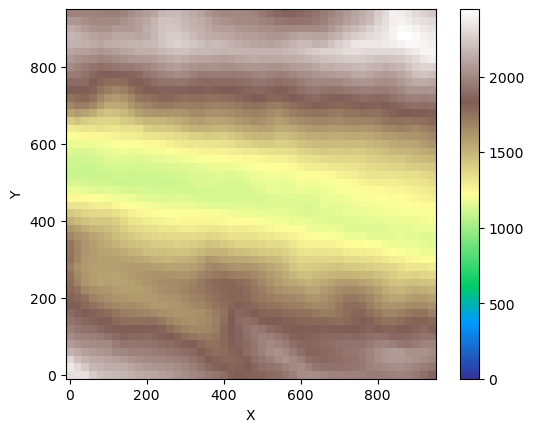

In [13]:
z = np.flipud(longs_peak.values.squeeze())
grid = RasterModelGrid(z.shape, xy_spacing=(20.0, 20.0))
grid.at_node["topographic__elevation"] = z
grid.imshow("topographic__elevation", cmap="terrain", vmin=0)

In [15]:
slice=grid.at_node["topographic__elevation"][grid.node_x==500]
plt.plot(slice)

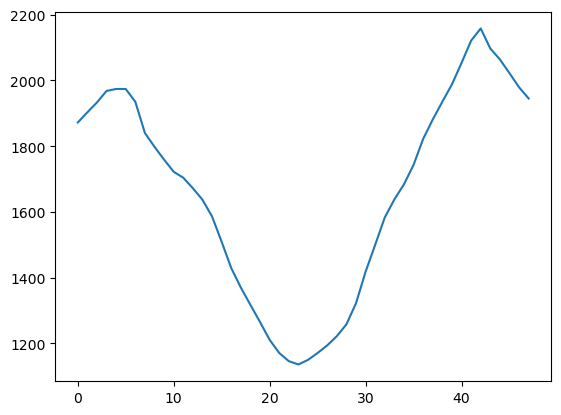